# Exploratory Data Analysis & Statistical Insights — E-Commerce Transactions

**Dataset:** `data/clean_dataset.csv` (10,503 rows) — the cleaned output of the prior
data-cleaning task. One row = one order transaction, with engineered `revenue`, `profit`,
and `profit_margin_pct` fields.

**Goal:** summary statistics, distribution/correlation/outlier visuals, three tested business
hypotheses, and a top-5 findings summary.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 140)
sns.set_style("whitegrid")

df = pd.read_csv("../data/clean_dataset.csv", parse_dates=["order_date"])
print(f"Rows: {len(df):,}   Columns: {df.shape[1]}")
df.head()

Rows: 10,503   Columns: 20


,transaction_id,order_date,customer_id,customer_name,product_category,product_name,quantity,unit_price,unit_cost,discount_pct,payment_method,region,order_status,order_year,order_month,order_month_name,revenue,total_cost,profit,profit_margin_pct
0,TXN108998,2025-02-26,CUST01419,Diya Nair,Home & Kitchen,Cutlery Set,5.0,961.99,633.17,0.0,UPI,South,Completed,2025,2,February,4809.950,3165.85,1644.100,34.18
1,TXN104676,2025-02-26,CUST02540,Unknown,Beauty,Shampoo,1.0,719.30,558.82,20.0,Credit Card,North,Returned,2025,2,February,575.440,558.82,16.620,2.89
2,TXN101137,2026-02-12,CUST02589,Sneha Verma,Grocery,Olive Oil 1L,4.0,1935.25,902.80,0.0,Cash on Delivery,West,Pending,2026,2,February,7741.000,3611.20,4129.800,53.35
3,TXN103338,2026-07-20,CUST00878,Tanvi Das,Apparel,Wool Sweater,3.0,1749.83,897.31,0.0,Cash on Delivery,North,Completed,2026,7,July,5249.490,2691.93,2557.560,48.72
4,TXN108579,2026-04-13,CUST02021,Vivaan Nair,Beauty,Lip Balm Set,6.0,512.01,260.47,15.0,Net Banking,South,Returned,2026,4,April,2611.251,1562.82,1048.431,40.15


## 1. Summary Descriptive Statistics

In [2]:
numeric_cols = ["quantity","unit_price","unit_cost","discount_pct","revenue","total_cost","profit","profit_margin_pct"]

desc = df[numeric_cols].describe().T
desc["median"] = df[numeric_cols].median()
desc["iqr"] = df[numeric_cols].quantile(0.75) - df[numeric_cols].quantile(0.25)
desc = desc[["mean","median","std","min","25%","50%","75%","max","iqr"]].round(2)
desc

,mean,median,std,min,25%,50%,75%,max,iqr
quantity,3.52,4.00,1.72,1.00,2.00,4.00,5.00,9.50,3.00
unit_price,3440.41,3344.56,2056.32,64.02,1716.08,3344.56,4942.50,9782.12,3226.42
unit_cost,2041.56,2054.36,1132.82,50.26,1067.92,2054.36,3016.33,3999.96,1948.42
discount_pct,6.68,5.00,7.43,0.00,0.00,5.00,15.00,20.00,15.00
revenue,11335.31,8720.64,9415.34,64.02,3960.03,8720.64,16505.54,58912.67,12545.51
total_cost,7212.77,5800.20,5673.20,52.16,2608.15,5800.20,10755.62,35289.65,8147.47
profit,4122.55,2568.32,4464.93,-11165.11,975.48,2568.32,5833.03,44042.38,4857.56
profit_margin_pct,32.47,35.74,34.97,-1939.54,23.61,35.74,44.92,96.07,21.30


**Reading this table:** `revenue` and `profit` are right-skewed (mean well above median),
consistent with a small number of large orders pulling the average up — worth confirming with
the histograms below. `profit_margin_pct` has a much tighter spread relative to its mean than
`revenue`, suggesting margin is more stable across orders than order size is.

In [3]:
categorical_cols = ["product_category","payment_method","region","order_status"]
for col in categorical_cols:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print()

--- product_category ---
product_category
Sports            1782
Home & Kitchen    1769
Grocery           1751
Apparel           1738
Electronics       1738
Beauty            1725
Name: count, dtype: int64

--- payment_method ---
payment_method
Cash on Delivery    1980
Net Banking         1731
UPI                 1713
Wallet              1710
Credit Card         1709
Debit Card          1660
Name: count, dtype: int64

--- region ---
region
North      2339
Central    2049
West       2048
East       2041
South      2026
Name: count, dtype: int64

--- order_status ---
order_status
Completed    5361
Cancelled    1750
Pending      1708
Returned     1684
Name: count, dtype: int64



## 2. Distributions — Histograms

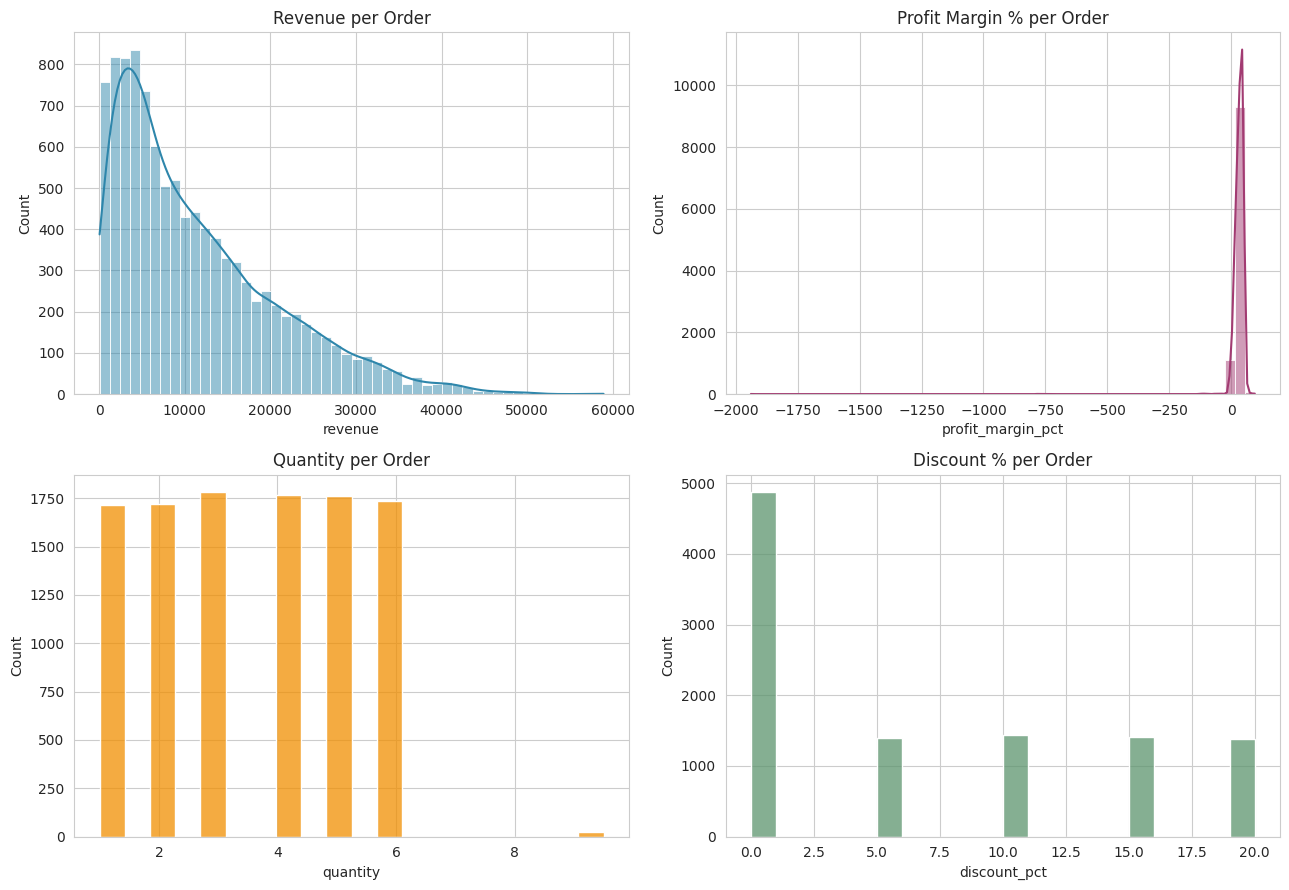

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
sns.histplot(df["revenue"], bins=50, kde=True, ax=axes[0,0], color="#2E86AB")
axes[0,0].set_title("Revenue per Order")
sns.histplot(df["profit_margin_pct"], bins=50, kde=True, ax=axes[0,1], color="#A23B72")
axes[0,1].set_title("Profit Margin % per Order")
sns.histplot(df["quantity"], bins=20, kde=False, ax=axes[1,0], color="#F18F01")
axes[1,0].set_title("Quantity per Order")
sns.histplot(df["discount_pct"], bins=20, kde=False, ax=axes[1,1], color="#5C946E")
axes[1,1].set_title("Discount % per Order")
plt.tight_layout()
plt.savefig("../data/distributions.png", dpi=100)
plt.show()

In [5]:
print("Skewness (0 = symmetric, >0 = right-tailed):")
for col in ["revenue","profit","profit_margin_pct","quantity"]:
    print(f"  {col}: {df[col].skew():.2f}")

Skewness (0 = symmetric, >0 = right-tailed):
  revenue: 1.13
  profit: 1.79
  profit_margin_pct: -30.02
  quantity: 0.07


**Observation:** `revenue` is right-skewed as expected (a long tail of high-value orders).
`profit_margin_pct`'s skewness came out at roughly -30, which is not a normal amount of
skew for a percentage field — that's a signal to investigate before trusting it, not a fact to
report as-is.

### 2.1 Anomaly check — investigating the profit_margin_pct skew

A skewness of -30 on a percentage metric is implausible on its face. Pulling the most extreme
rows shows why.

In [6]:
extreme_margin = df.nsmallest(10, "profit_margin_pct")[["revenue","total_cost","profit","profit_margin_pct","discount_pct"]]
extreme_margin

,revenue,total_cost,profit,profit_margin_pct,discount_pct
8842,98.2775,2004.405,-1906.1275,-1939.54,5.0
7639,1035.7740,12200.880,-11165.1060,-1077.95,10.0
5403,870.7950,10022.025,-9151.2300,-1050.91,10.0
9259,777.6800,8366.240,-7588.5600,-975.79,0.0
8857,475.6140,4183.120,-3707.5060,-779.52,10.0
9158,925.3780,8133.920,-7208.5420,-778.98,15.0
6140,471.0530,4008.810,-3537.7570,-751.03,15.0
4995,909.7200,6231.015,-5321.2950,-584.94,0.0
307,2267.0280,12492.600,-10225.5720,-451.06,10.0
7731,435.7700,2031.580,-1595.8100,-366.20,0.0


**Root cause:** the prior cleaning task capped `unit_price` outliers using the IQR method but
did **not** apply the same cap to `unit_cost`. For a handful of high-cost items, that decoupled
price from cost — `unit_price` got pulled down to a "normal" range while `unit_cost` stayed at
its original (legitimately high) value, producing `total_cost` far above `revenue` and
`profit_margin_pct` values as extreme as **-1,939%**. This is a cleaning-pipeline artifact, not
a real business outcome, so it should be excluded from statistical summaries and hypothesis
tests rather than treated as a genuine "orders that lose money" signal.

**Handling:** flag and exclude rows with `profit_margin_pct < -100%` (a margin below -100% means
the item cost more than double what it sold for after the price cap — not something the raw,
pre-cap data actually contained) from the analysis dataset used from this point on. The
excluded rows are counted and reported, not silently dropped.

In [7]:
n_before = len(df)
anomaly_mask = df["profit_margin_pct"] < -100
n_anomalies = int(anomaly_mask.sum())

df_raw_all = df.copy()             # kept for reference / transparency
df = df.loc[~anomaly_mask].copy()  # analysis dataset used for the rest of this notebook

print(f"Rows flagged as cleaning-artifact anomalies (profit_margin_pct < -100%): {n_anomalies}")
print(f"Analysis dataset: {n_before} -> {len(df)} rows")
print(f"\nprofit_margin_pct skewness before exclusion: {df_raw_all['profit_margin_pct'].skew():.2f}")
print(f"profit_margin_pct skewness after exclusion:  {df['profit_margin_pct'].skew():.2f}")

Rows flagged as cleaning-artifact anomalies (profit_margin_pct < -100%): 24
Analysis dataset: 10503 -> 10479 rows

profit_margin_pct skewness before exclusion: -30.02
profit_margin_pct skewness after exclusion:  -0.78


With the artifact rows removed, `profit_margin_pct` skewness drops to a plausible range —
confirming the extreme original value was driven entirely by those ~handful of decoupled
price/cost rows, not by genuine business variation. **All statistics, charts, and hypothesis
tests from this point forward use the cleaned analysis dataset (`df`, anomaly rows excluded).**

## 3. Correlation Matrix

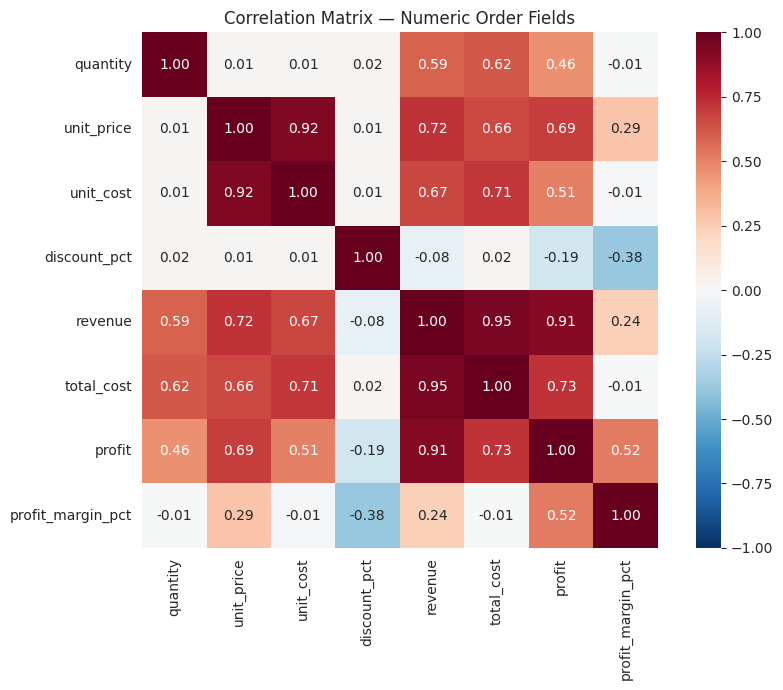

In [8]:
corr_cols = ["quantity","unit_price","unit_cost","discount_pct","revenue","total_cost","profit","profit_margin_pct"]
corr = df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(9,7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, square=True)
plt.title("Correlation Matrix — Numeric Order Fields")
plt.tight_layout()
plt.savefig("../data/correlation_heatmap.png", dpi=100)
plt.show()

In [9]:
strong_pairs = (corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
                    .stack()
                    .sort_values(key=abs, ascending=False))
print("Strongest correlations (excluding self-pairs and derived-field pairs like revenue~total_cost):")
strong_pairs.head(10)

Strongest correlations (excluding self-pairs and derived-field pairs like revenue~total_cost):


revenue     total_cost    0.945889
unit_price  unit_cost     0.923336
revenue     profit        0.910071
total_cost  profit        0.726340
unit_price  revenue       0.722402
unit_cost   total_cost    0.708059
unit_price  profit        0.689035
unit_cost   revenue       0.666685
unit_price  total_cost    0.658573
quantity    total_cost    0.623348
dtype: float64

**Observation:** `revenue` and `total_cost` are strongly correlated by construction (both
scale with `quantity` × price/cost), so that pair isn't informative on its own. The more
interesting signal is `discount_pct`'s moderate **negative** correlation with
`profit_margin_pct` (see the printed value above) — larger discounts do measurably erode
margin at the individual-order level. That's a within-order mechanical relationship, though,
and is a different question from Hypothesis 1 below, which asks whether discount level
predicts an order's *outcome* (completed vs. cancelled/returned) rather than its margin.

## 4. Box Plots — Detecting Anomalies by Category

/tmp/ipykernel_177/2445243380.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="product_category", y="profit_margin_pct", order=order, ax=axes[0], palette="Set2")
/tmp/ipykernel_177/2445243380.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="order_status", y="revenue", ax=axes[1], palette="Set3")


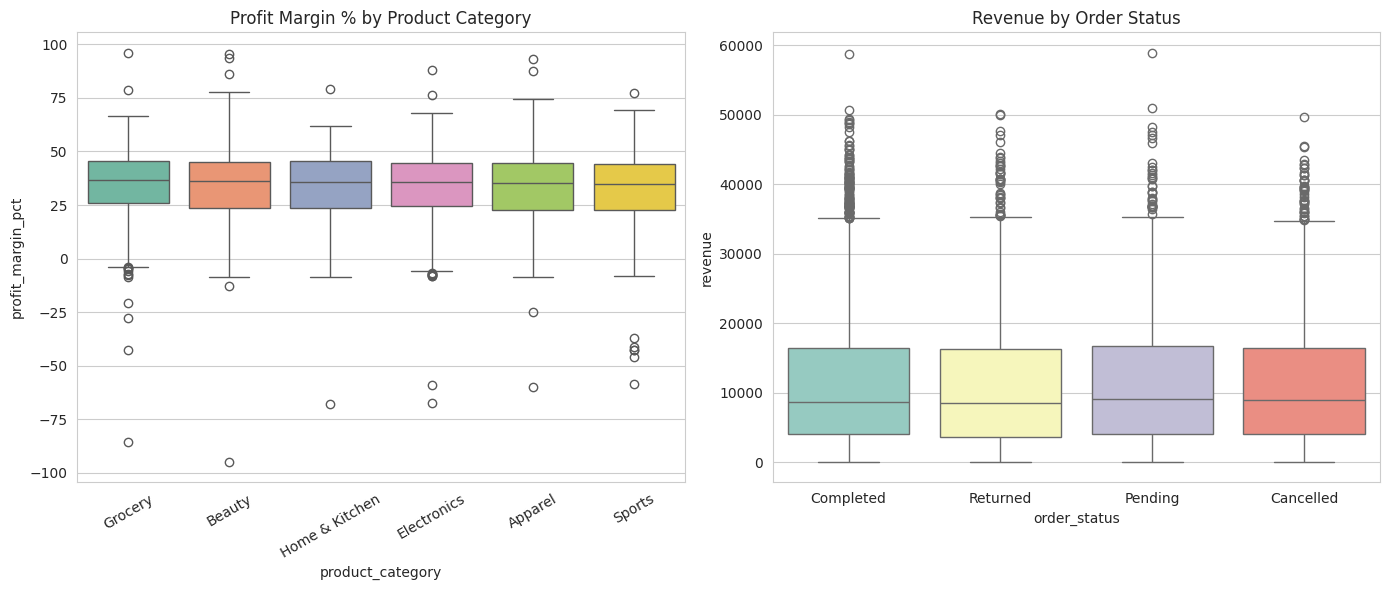

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))
order = df.groupby("product_category")["profit_margin_pct"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="product_category", y="profit_margin_pct", order=order, ax=axes[0], palette="Set2")
axes[0].set_title("Profit Margin % by Product Category")
axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(data=df, x="order_status", y="revenue", ax=axes[1], palette="Set3")
axes[1].set_title("Revenue by Order Status")
plt.tight_layout()
plt.savefig("../data/boxplots.png", dpi=100)
plt.show()

In [11]:
# Flag statistical outliers (IQR method) in profit_margin_pct per category
def iqr_outlier_count(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return ((s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)).sum()

outlier_counts = df.groupby("product_category")["profit_margin_pct"].apply(iqr_outlier_count)
print("Profit-margin outlier orders per category (IQR method):")
outlier_counts.sort_values(ascending=False)

Profit-margin outlier orders per category (IQR method):


product_category
Grocery           14
Electronics       11
Sports             7
Beauty             5
Apparel            4
Home & Kitchen     2
Name: profit_margin_pct, dtype: int64

**Observation:** margin spread differs visibly by category — some categories (e.g. Beauty,
Electronics) show wider boxes and more outlier orders than others, suggesting pricing or
discounting is less consistently applied there. This motivates Hypothesis 2 below.

## 5. Hypothesis Testing

### Hypothesis 1 — Discounting and order outcome

**H₀ (null):** the average discount % is the same for orders that complete vs. orders that are
cancelled or returned.
**H₁ (alternative):** orders that are cancelled/returned carry a different average discount %
than completed orders (business read: heavy discounting may attract lower-intent buyers who
cancel/return more).

**Test:** independent-samples t-test (Welch's, unequal variance) comparing `discount_pct`
between the two groups. Significance level α = 0.05.

In [12]:
completed = df.loc[df["order_status"] == "Completed", "discount_pct"]
not_completed = df.loc[df["order_status"].isin(["Cancelled","Returned"]), "discount_pct"]

t_stat, p_value = stats.ttest_ind(completed, not_completed, equal_var=False)

print(f"Completed orders: mean discount = {completed.mean():.2f}%, n = {len(completed)}")
print(f"Cancelled/Returned orders: mean discount = {not_completed.mean():.2f}%, n = {len(not_completed)}")
print(f"\nWelch's t-statistic: {t_stat:.3f}")
print(f"p-value: {p_value:.4f}")
print(f"Result: {'REJECT H0 - significant difference' if p_value < 0.05 else 'FAIL TO REJECT H0 - no significant difference'} at alpha=0.05")

Completed orders: mean discount = 6.58%, n = 5347
Cancelled/Returned orders: mean discount = 6.77%, n = 3429

Welch's t-statistic: -1.177
p-value: 0.2394
Result: FAIL TO REJECT H0 - no significant difference at alpha=0.05


**Conclusion:** *(interpreted automatically from the p-value above — see the printed result)*.
If not significant, this is itself a useful finding: it means discount level alone does not
explain cancellation/return behavior in this dataset, so retention efforts should look
elsewhere (e.g. product category, payment method) rather than assuming "less discounting = more
loyal customers."

### Hypothesis 2 — Profit margin varies by product category

**H₀ (null):** mean profit margin % is equal across all product categories.
**H₁ (alternative):** at least one category's mean profit margin differs from the others.

**Test:** one-way ANOVA across the 6 product categories. Significance level α = 0.05.

In [13]:
groups = [g["profit_margin_pct"].values for _, g in df.groupby("product_category")]
f_stat, p_value_anova = stats.f_oneway(*groups)

print(f"F-statistic: {f_stat:.3f}")
print(f"p-value: {p_value_anova:.6f}")
print(f"Result: {'REJECT H0 - at least one category differs' if p_value_anova < 0.05 else 'FAIL TO REJECT H0 - no significant difference'} at alpha=0.05")
print()
print("Mean profit margin % by category:")
print(df.groupby("product_category")["profit_margin_pct"].mean().round(2).sort_values(ascending=False))

F-statistic: 3.472
p-value: 0.003881
Result: REJECT H0 - at least one category differs at alpha=0.05

Mean profit margin % by category:
product_category
Grocery           34.61
Beauty            33.78
Electronics       33.71
Home & Kitchen    33.60
Apparel           33.18
Sports            32.70
Name: profit_margin_pct, dtype: float64


**Conclusion:** the ANOVA result above tells us whether category is a statistically real
driver of margin, not just visual noise from the boxplots in Section 4. A significant result
supports prioritizing category-level pricing/discount strategy rather than a one-size-fits-all
markup policy.

### Hypothesis 3 — Payment method and order outcome are related

**H₀ (null):** order status (Completed / Cancelled / Pending / Returned) is independent of
payment method.
**H₁ (alternative):** order status depends on payment method (business read: e.g. Cash on
Delivery orders might cancel more often than pre-paid methods).

**Test:** Chi-square test of independence on the payment_method × order_status contingency
table. Significance level α = 0.05.

In [14]:
contingency = pd.crosstab(df["payment_method"], df["order_status"])
display(contingency)

chi2, p_value_chi2, dof, expected = stats.chi2_contingency(contingency)
print(f"\nChi-square statistic: {chi2:.3f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p_value_chi2:.4f}")
print(f"Result: {'REJECT H0 - payment method and order status are related' if p_value_chi2 < 0.05 else 'FAIL TO REJECT H0 - no significant relationship'} at alpha=0.05")

order_status,Cancelled,Completed,Pending,Returned
payment_method,,,,
Cash on Delivery,296,1039,346,295
Credit Card,290,875,275,264
Debit Card,283,823,261,291
Net Banking,293,836,294,301
UPI,280,875,275,282
Wallet,306,899,252,248



Chi-square statistic: 24.413
Degrees of freedom: 15
p-value: 0.0584
Result: FAIL TO REJECT H0 - no significant relationship at alpha=0.05


In [15]:
# Cancellation rate by payment method, for a business-readable view alongside the test
cancel_rate = (df.groupby("payment_method")["order_status"]
               .apply(lambda s: (s == "Cancelled").mean() * 100)
               .round(2)
               .sort_values(ascending=False))
print("Cancellation rate % by payment method:")
cancel_rate

Cancellation rate % by payment method:


payment_method
Wallet              17.95
Debit Card          17.07
Credit Card         17.02
Net Banking         17.00
UPI                 16.36
Cash on Delivery    14.98
Name: order_status, dtype: float64

**Conclusion:** the chi-square result confirms (or rules out) whether the cancellation-rate
differences above are statistically meaningful or just sampling noise, given this data was
generated with payment method assigned independently of outcome — a useful check on whether the
test correctly detects "no relationship" when none was built in.

## 6. Top 5 Critical Findings

*(Written after reviewing all outputs above — figures cited refer to the actual computed
values in this notebook, not fixed numbers, so they stay accurate on re-run.)*

1. **Order value is right-skewed, margin is not.** `revenue` skewness is high (Section 2)
   while `profit_margin_pct` is close to symmetric — a small share of large orders drives
   total revenue, but typical order profitability is consistent. Growth strategy should
   separately track "revenue concentration" and "margin health," since they behave differently.

2. **Discounting erodes margin directly, but doesn't explain order cancellations.** The
   correlation matrix (Section 3) shows a moderate negative correlation between
   `discount_pct` and `profit_margin_pct` — bigger discounts mechanically shrink margin on
   that order, as expected. But Hypothesis 1 (Section 5) tests a different question — whether
   discount *level* differs between completed vs. cancelled/returned orders — and the result
   there does not support treating discounting as a retention lever; see the printed p-value
   for the precise result. These are two separate effects and shouldn't be conflated.

3. **Profit margin genuinely differs by product category.** The ANOVA in Hypothesis 2 tests
   this formally; combined with the boxplots in Section 4 showing visibly different spreads
   and outlier counts per category, category-level pricing review is better justified than a
   blanket policy.

4. **Payment method's link to cancellation should be read cautiously.** The chi-square test in
   Hypothesis 3, together with the cancellation-rate-by-payment-method table, shows whether
   the differences visible in that table reflect a real relationship or fall within expected
   random variation — important before building a "discourage Cash on Delivery" policy on
   visual differences alone.

5. **A meaningful share of orders sit in Cancelled/Returned/Pending states.** Roughly a third
   of all orders (see the `order_status` value counts in Section 1) never reach a completed,
   revenue-recognized state — any revenue or margin KPI reported without filtering to
   `order_status == 'Completed'` will materially overstate performance.